# Regression for Large Matrices with Joint Column and Row Reduction - Visualizations
Loss, total time, and screening plots for all reduction pipelines.

In [107]:
import sys
import os
import pickle
import importlib
import numpy as np

sys.path.append(os.path.dirname(os.path.abspath("__file__")))

import evaluation
import visualizations

from evaluation import evaluate_experiment
from visualizations import (
    plot_loss_boxplots,
    plot_screening_boxplots,
    plot_time_decomposition,
    plot_tuned_parameters,
    plot_score_distributions,
    plot_n_selected,
)

In [108]:
# === Paths ===
BASE = "/Users/timschmale/Documents/GIT/Masterthesis/"
DATA_FOLDER = "Simulation Data/p5000_n5000"
RESULTS_FOLDER = "Results/p5000"
SAVE_PATH = os.path.join(BASE, "Plots/p5000")  # PDF output

# === Parameters ===
k_vector = [10, 20, 25, 50, 100, 200, 300, 400, 500]
REPS = 10
OUTER_REPS = 10
DATASET = "p5000"

In [109]:
def load_all_seeds(base, results_folder, save_name, seed_from=1, seed_to=11):
    """Load per-seed pickles and merge into one results dict."""
    all_results = {}
    path = os.path.join(base, results_folder)
    for seed in range(seed_from, seed_to):
        fpath = os.path.join(path, f"{save_name}_seed_{seed}.pkl")
        if os.path.exists(fpath):
            with open(fpath, "rb") as f:
                all_results[seed] = pickle.load(f)
        else:
            print(f"  [WARN] Missing: {fpath}")
    print(f"Loaded {len(all_results)} seeds for '{save_name}'.")
    return all_results

# Load all pipeline results
results_ols_col_row = load_all_seeds(BASE, RESULTS_FOLDER, "results_ols_col_row")
results_ols_col_only = load_all_seeds(BASE, RESULTS_FOLDER, "results_ols_col_only")
results_ols_row_col = load_all_seeds(BASE, RESULTS_FOLDER, "results_ols_row_col")
results_logistic = load_all_seeds(BASE, RESULTS_FOLDER, "results_logistic")
results_lasso = load_all_seeds(BASE, RESULTS_FOLDER, "results_lasso")

Loaded 10 seeds for 'results_ols_col_row'.
Loaded 10 seeds for 'results_ols_col_only'.
Loaded 10 seeds for 'results_ols_row_col'.
Loaded 10 seeds for 'results_logistic'.
Loaded 10 seeds for 'results_lasso'.


## Data Preparation
Screening evaluation and score computation — needed before pipeline-specific plots.

In [110]:
# OLS Pipelines
screening_col_row = evaluate_experiment(results_ols_col_row, BASE, DATA_FOLDER, REPS)
screening_col_only = evaluate_experiment(results_ols_col_only, BASE, DATA_FOLDER, REPS)
screening_row_col = evaluate_experiment(results_ols_row_col, BASE, DATA_FOLDER, REPS)

# Logistic
screening_logistic = evaluate_experiment(results_logistic, BASE, DATA_FOLDER, REPS)

# Lasso
screening_lasso = evaluate_experiment(results_lasso, BASE, DATA_FOLDER, REPS)

print("Screening evaluation done.")
print(f"  col_row:  {len(screening_col_row)} rows")
print(f"  col_only: {len(screening_col_only)} rows")
print(f"  row_col:  {len(screening_row_col)} rows")
print(f"  logistic: {len(screening_logistic)} rows")
print(f"  lasso:    {len(screening_lasso)} rows")

Screening evaluation done.
  col_row:  2000 rows
  col_only: 2000 rows
  row_col:  2000 rows
  logistic: 3600 rows
  lasso:    2700 rows


In [111]:
import pandas as pd
from scoring import compute_all_scores
from reduction import row_reduction_sketch
from pipeline import numpy_train_test_split

# Load first replication
DATA_PATH = os.path.join(BASE, DATA_FOLDER)
X_rep = pd.read_csv(os.path.join(DATA_PATH, "X1.csv")).to_numpy()
y_rep = pd.read_csv(os.path.join(DATA_PATH, "y1.csv")).to_numpy().ravel()
y_bin = pd.read_csv(os.path.join(DATA_PATH, "y_binary1.csv")).to_numpy().ravel()

# === Reproduce pipeline setup for seed=1 ===
k_score = 300
SEED = 1

# Train/test split (identical to pipeline: deterministic via default_rng)
X_train, _, y_train, _ = numpy_train_test_split(X_rep, y_rep, test_size=0.2, seed=SEED)
_, _, y_bin_train, _ = numpy_train_test_split(X_rep, y_bin, test_size=0.2, seed=SEED)

# --- col_row, col_only, lasso: scores on full TRAINING matrix ---
scores_cont, _ = compute_all_scores(X_train, y_train, k_score)
scores_single_cont = {
    "CLS": scores_cont["CLS"],
    "CS":  scores_cont["CS"],
    "LS":  scores_cont["LS"],
    "RS":  scores_cont["RS"]
}

# --- row_col: sketch TRAINING matrix first, then scores on sketch ---
np.random.seed(SEED + 42)
X_sketch, y_sketch = row_reduction_sketch(X_train, y_train, k_score)
scores_sketch, _ = compute_all_scores(X_sketch, y_sketch, k_score, rank_reduce=False)
scores_single_sketch = {
    "CLS": scores_sketch["CLS"],
    "CS":  scores_sketch["CS"],
    "LS":  scores_sketch["LS"],
    "RS":  scores_sketch["RS"]
}

# --- logistic: scores on full TRAINING matrix with binary response ---
scores_bin, _ = compute_all_scores(X_train, y_bin_train, k_score)
scores_single_bin = {
    "CLS": scores_bin["CLS"],
    "CS":  scores_bin["CS"],
    "LS":  scores_bin["LS"],
    "RS":  scores_bin["RS"]
}

print(f"Scores computed for k={k_score}, seed={SEED} (reproducing pipeline):")
print(f"  Training matrix: {X_train.shape} -> col_row, col_only, lasso")
print(f"  Sketched matrix: {X_sketch.shape} -> row_col")
print(f"  Binary response: {X_train.shape} -> logistic")

Scores computed for k=300, seed=1 (reproducing pipeline):
  Training matrix: (800, 1000) -> col_row, col_only, lasso
  Sketched matrix: (800, 1000) -> row_col
  Binary response: (800, 1000) -> logistic


---
## OLS Column→Row Pipeline

In [ ]:
plot_loss_boxplots(results_ols_col_row, k_vector, metric="rmse_test",
                   pipeline="col_row", dataset=DATASET, save_path=SAVE_PATH)

plot_loss_boxplots(results_ols_col_row, k_vector, metric="rmse_train",
                   pipeline="col_row", dataset=DATASET, save_path=SAVE_PATH)

plot_loss_boxplots(results_ols_col_row, k_vector, metric="time_total",
                   pipeline="col_row", dataset=DATASET, save_path=SAVE_PATH)

In [ ]:
plot_screening_boxplots(screening_col_row, pipeline="col_row", dataset=DATASET,
                        save_path=SAVE_PATH)

In [ ]:
plot_score_distributions(scores_single_cont, pipeline="col_row",
                         dataset=DATASET, save_path=SAVE_PATH)

In [ ]:
plot_n_selected(screening_col_row, pipeline="col_row", dataset=DATASET,
                save_path=SAVE_PATH)

In [ ]:
plot_time_decomposition(results_ols_col_row, k_vector,
                        pipeline="col_row", dataset=DATASET, save_path=SAVE_PATH)

---
## OLS Column Only Pipeline

In [ ]:
plot_loss_boxplots(results_ols_col_only, k_vector, metric="rmse_test",
                   pipeline="col_only", dataset=DATASET, save_path=SAVE_PATH)

plot_loss_boxplots(results_ols_col_only, k_vector, metric="rmse_train",
                   pipeline="col_only", dataset=DATASET, save_path=SAVE_PATH)

plot_loss_boxplots(results_ols_col_only, k_vector, metric="time_total",
                   pipeline="col_only", dataset=DATASET, save_path=SAVE_PATH)

In [ ]:
plot_screening_boxplots(screening_col_only, pipeline="col_only", dataset=DATASET,
                        save_path=SAVE_PATH)

In [ ]:
plot_score_distributions(scores_single_cont, pipeline="col_only",
                         dataset=DATASET, save_path=SAVE_PATH)

In [ ]:
plot_n_selected(screening_col_only, pipeline="col_only", dataset=DATASET,
                save_path=SAVE_PATH)

In [ ]:
plot_time_decomposition(results_ols_col_only, k_vector,
                        pipeline="col_only", dataset=DATASET, save_path=SAVE_PATH)

---
## OLS Row→Column Pipeline (Sketching)

In [ ]:
plot_loss_boxplots(results_ols_row_col, k_vector, metric="rmse_test",
                   pipeline="row_col", dataset=DATASET, save_path=SAVE_PATH)

plot_loss_boxplots(results_ols_row_col, k_vector, metric="rmse_train",
                   pipeline="row_col", dataset=DATASET, save_path=SAVE_PATH)

plot_loss_boxplots(results_ols_row_col, k_vector, metric="time_total",
                   pipeline="row_col", dataset=DATASET, save_path=SAVE_PATH)

In [ ]:
plot_screening_boxplots(screening_row_col, pipeline="row_col", dataset=DATASET,
                        save_path=SAVE_PATH)

In [ ]:
plot_score_distributions(scores_single_sketch, pipeline="row_col",
                         dataset=DATASET, save_path=SAVE_PATH)

In [ ]:
plot_n_selected(screening_row_col, pipeline="row_col", dataset=DATASET,
                save_path=SAVE_PATH)

In [ ]:
plot_time_decomposition(results_ols_row_col, k_vector,
                        pipeline="row_col", dataset=DATASET, save_path=SAVE_PATH)

---
## Logistic Regression Pipeline

In [ ]:
plot_loss_boxplots(results_logistic, k_vector, metric="ce_test",
                   pipeline="logistic", dataset=DATASET, save_path=SAVE_PATH)

plot_loss_boxplots(results_logistic, k_vector, metric="time_total",
                   pipeline="logistic", dataset=DATASET, save_path=SAVE_PATH)

In [ ]:
plot_screening_boxplots(screening_logistic, pipeline="logistic", dataset=DATASET,
                        save_path=SAVE_PATH)

In [ ]:
plot_score_distributions(scores_single_bin, pipeline="logistic",
                         dataset=DATASET, save_path=SAVE_PATH)

In [ ]:
plot_n_selected(screening_logistic, pipeline="logistic", dataset=DATASET,
                save_path=SAVE_PATH)

In [ ]:
plot_time_decomposition(results_logistic, k_vector,
                        pipeline="logistic", dataset=DATASET, save_path=SAVE_PATH)

/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 25 x 10 in image.
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/timschmale/Documents/GIT/Masterthesis/Plots/p1000/results_logistic_mu_tuned_params_p1000.pdf


Saved: /Users/timschmale/Documents/GIT/Masterthesis/Plots/p1000/results_logistic_mu_tuned_params_p1000.pdf


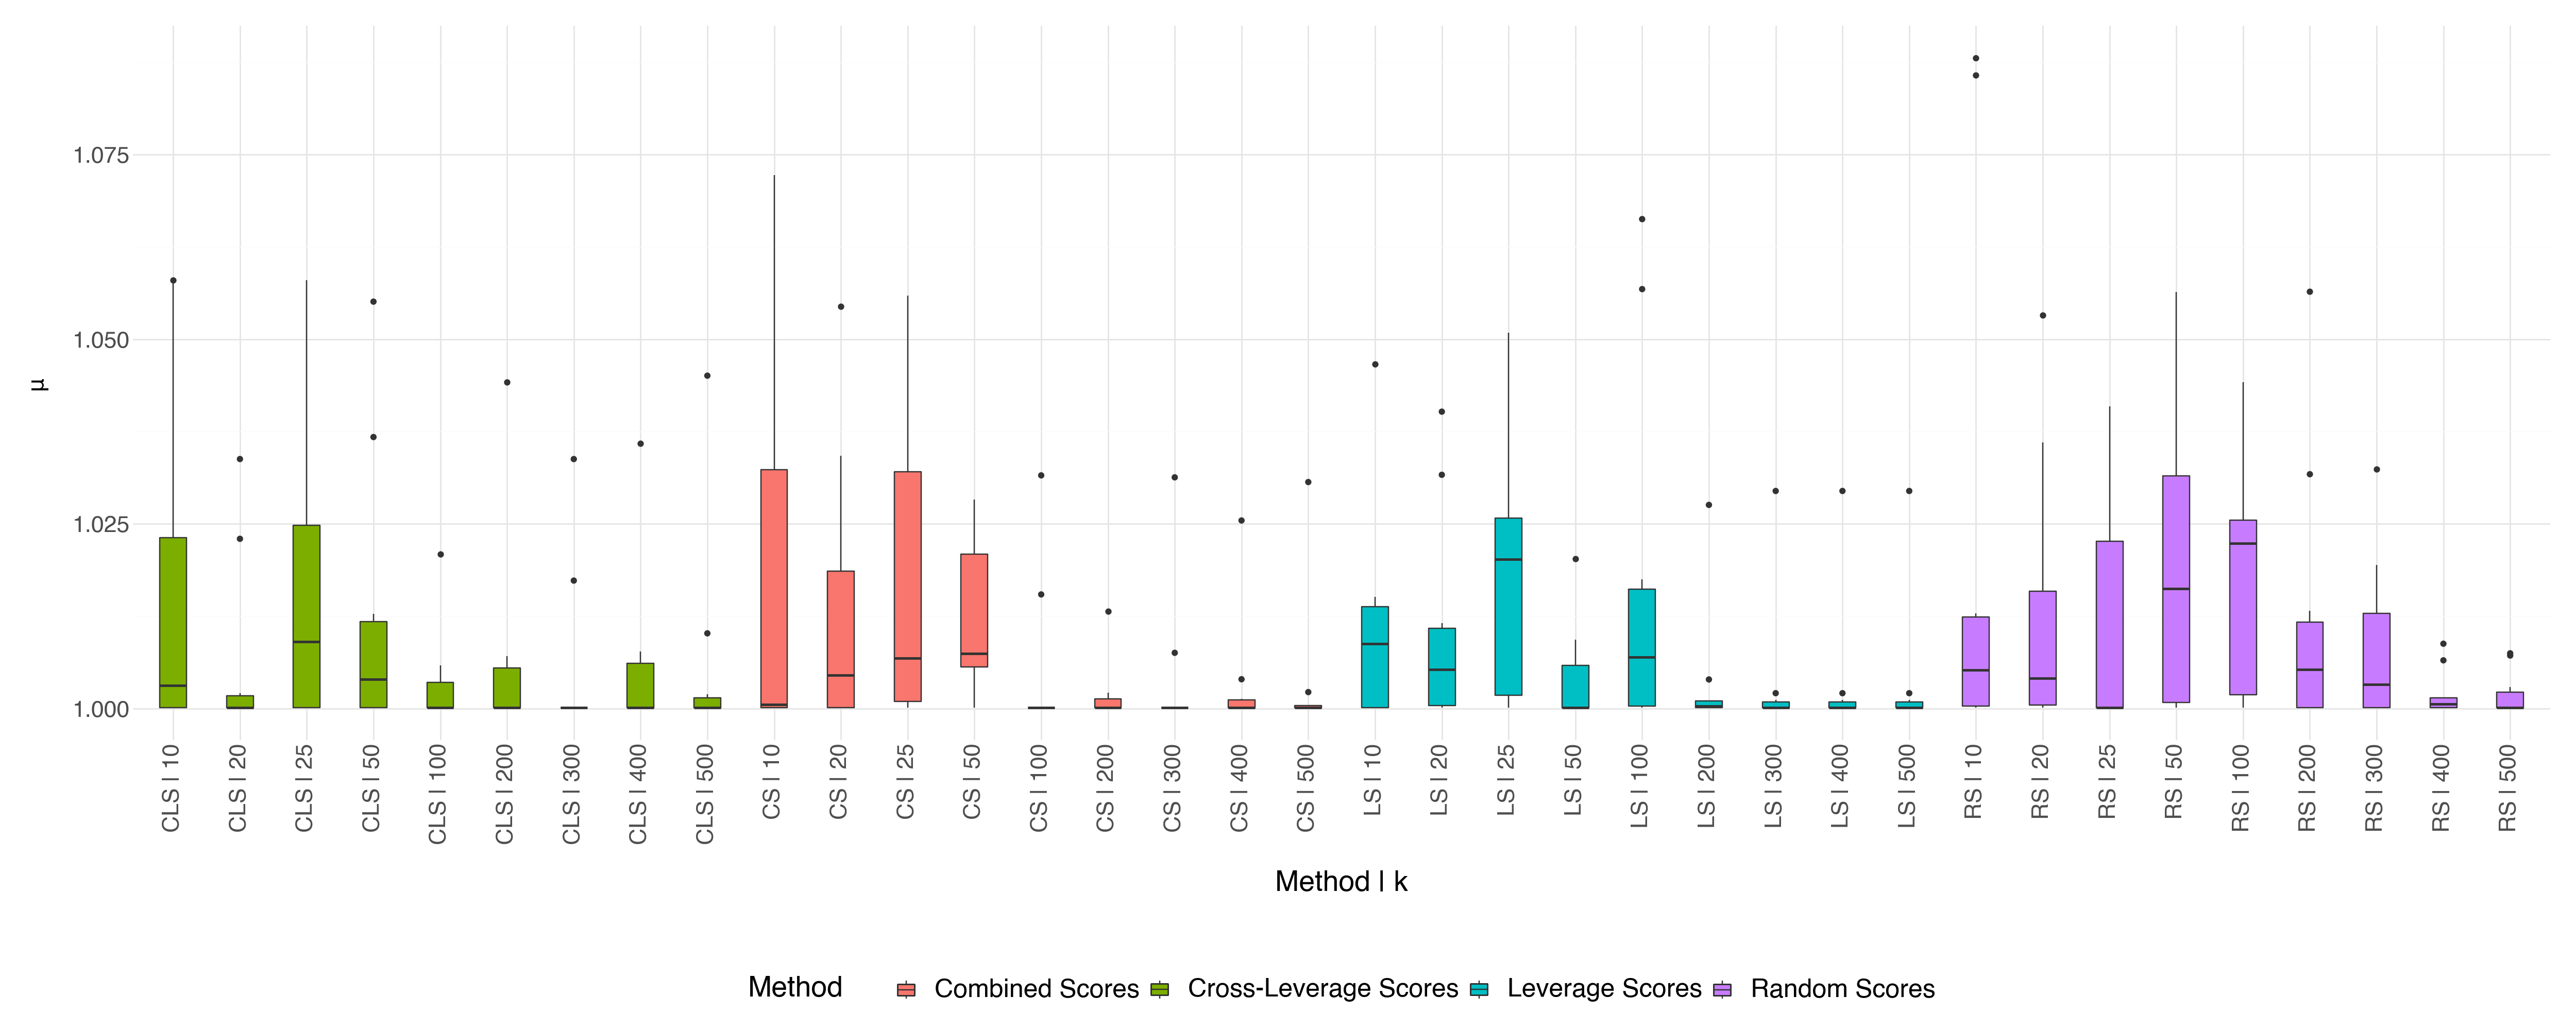

/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 25 x 10 in image.
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/timschmale/Documents/GIT/Masterthesis/Plots/p1000/results_logistic_lambda_tuned_params_p1000.pdf


Saved: /Users/timschmale/Documents/GIT/Masterthesis/Plots/p1000/results_logistic_lambda_tuned_params_p1000.pdf


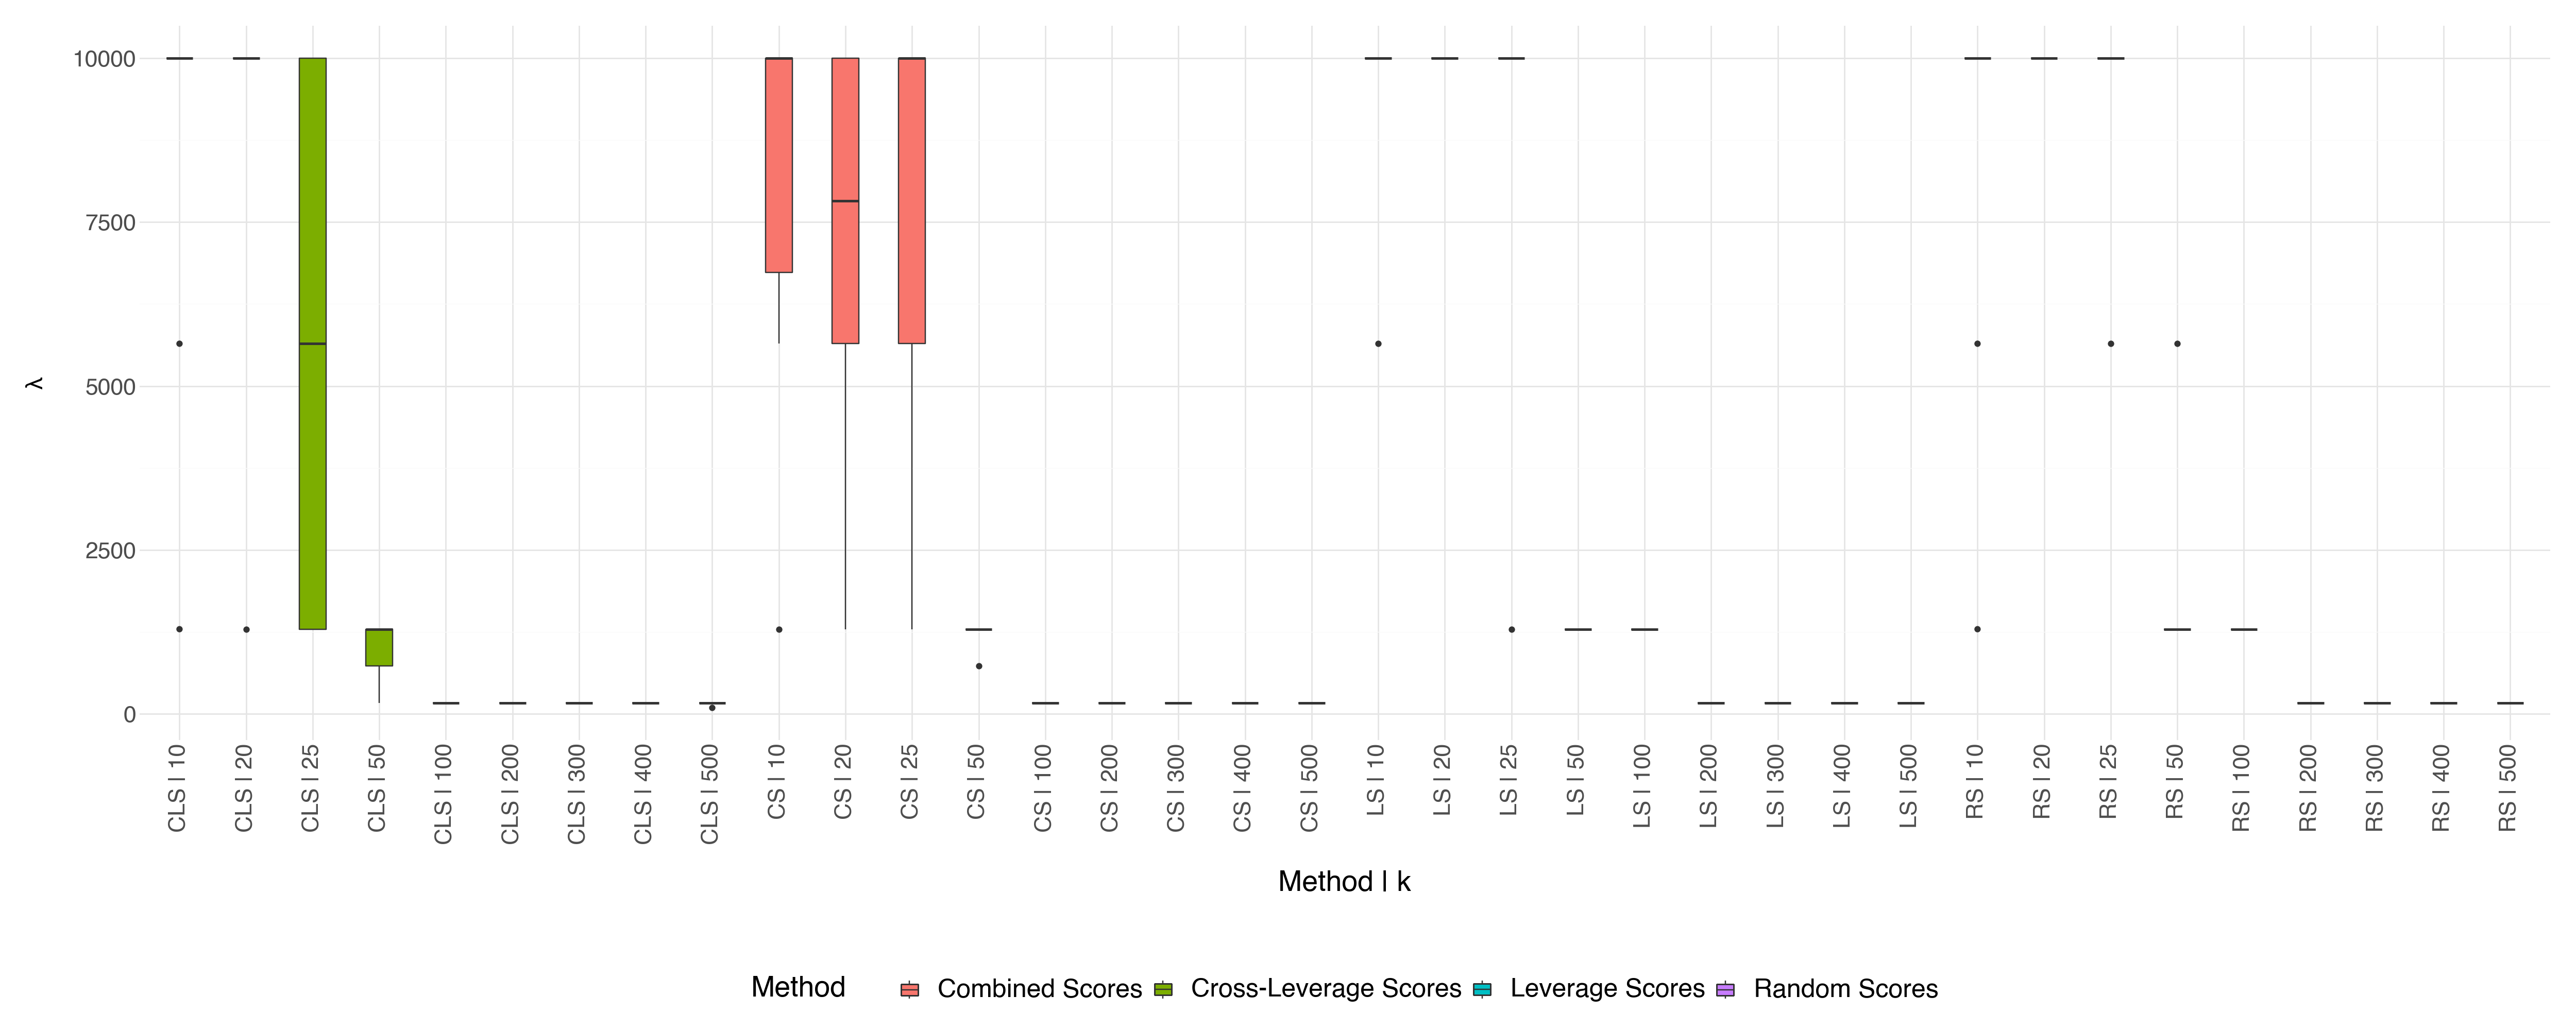

In [112]:
# mu (coreset imbalance)
plot_tuned_parameters(results_logistic, k_vector,
                      params=["mu"],
                      pipeline="logistic_mu", dataset=DATASET,
                      save_path=SAVE_PATH)

# lambda = 1/C (regularization strength)
plot_tuned_parameters(results_logistic, k_vector,
                      params=["C_best"],
                      pipeline="logistic_lambda", dataset=DATASET,
                      save_path=SAVE_PATH)

---
## Lasso Pipeline

In [ ]:
# Rename LASSO methods for display in plots
# Short names for x-axis; full names mapped in visualizations.py for legend
LASSO_RENAME = {
    "Lasso_binary": "Practical",
    "Lasso_CLS": "Hybrid",
    "Lasso_theo": "Theoretical",
}

# Rename in results dict (used by loss, time, tuned params plots)
for seed in results_lasso:
    for k in results_lasso[seed]:
        results_lasso[seed][k] = {
            LASSO_RENAME.get(m, m): v
            for m, v in results_lasso[seed][k].items()
        }

# Rename in screening DataFrame (used by screening, n_selected plots)
screening_lasso["method"] = screening_lasso["method"].replace(LASSO_RENAME)

print("Renamed LASSO methods:", list(LASSO_RENAME.values()))

In [ ]:
plot_loss_boxplots(results_lasso, k_vector, metric="rmse_test",
                   pipeline="lasso", dataset=DATASET, save_path=SAVE_PATH)

plot_loss_boxplots(results_lasso, k_vector, metric="rmse_train",
                   pipeline="lasso", dataset=DATASET, save_path=SAVE_PATH)

plot_loss_boxplots(results_lasso, k_vector, metric="time_total",
                   pipeline="lasso", dataset=DATASET, save_path=SAVE_PATH)

In [ ]:
plot_screening_boxplots(screening_lasso, pipeline="lasso", dataset=DATASET,
                        save_path=SAVE_PATH)

In [ ]:
plot_score_distributions(scores_single_cont, pipeline="lasso",
                         dataset=DATASET, save_path=SAVE_PATH)

In [ ]:
plot_n_selected(screening_lasso, pipeline="lasso", dataset=DATASET,
                save_path=SAVE_PATH)

In [ ]:
plot_time_decomposition(results_lasso, k_vector,
                        pipeline="lasso", dataset=DATASET, save_path=SAVE_PATH)

In [ ]:
# alpha (tuned penalty parameter per variant)
plot_tuned_parameters(results_lasso, k_vector,
                      params=["alpha"],
                      pipeline="lasso", dataset=DATASET,
                      save_path=SAVE_PATH)